# 06 - Market Opportunity Sizing
Combines Realtor.com-style market indicators (demand, supply, hotness) with
platform performance (activation, paid conversion, current penetration) into
a transparent, weighted opportunity score, built in `mart_market_opportunity`.
This is a prioritization framework for where to invest sales/marketing next,
not an objective measure of market value -- weights are explicit and we
stress-test them with a sensitivity analysis below.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/warehouse.db")
mo = pd.read_sql("SELECT * FROM mart_market_opportunity", conn)
mo[["metro_name", "demand_score", "low_penetration_norm", "activation_rate",
    "paid_conversion_rate", "opportunity_score", "market_classification"]].round(3)

## Market classification breakdown

In [2]:
print(mo["market_classification"].value_counts())
print()
print(mo.groupby("market_classification")["opportunity_score"].mean().round(3).sort_values(ascending=False))

market_classification
high_demand_low_penetration     11
low_demand_high_performance      8
high_demand_high_penetration     6
Name: count, dtype: int64

market_classification
high_demand_low_penetration     0.598
high_demand_high_penetration    0.454
low_demand_high_performance     0.390
Name: opportunity_score, dtype: float64


## Demand vs. penetration scatter (the classic 2x2 prioritization view)

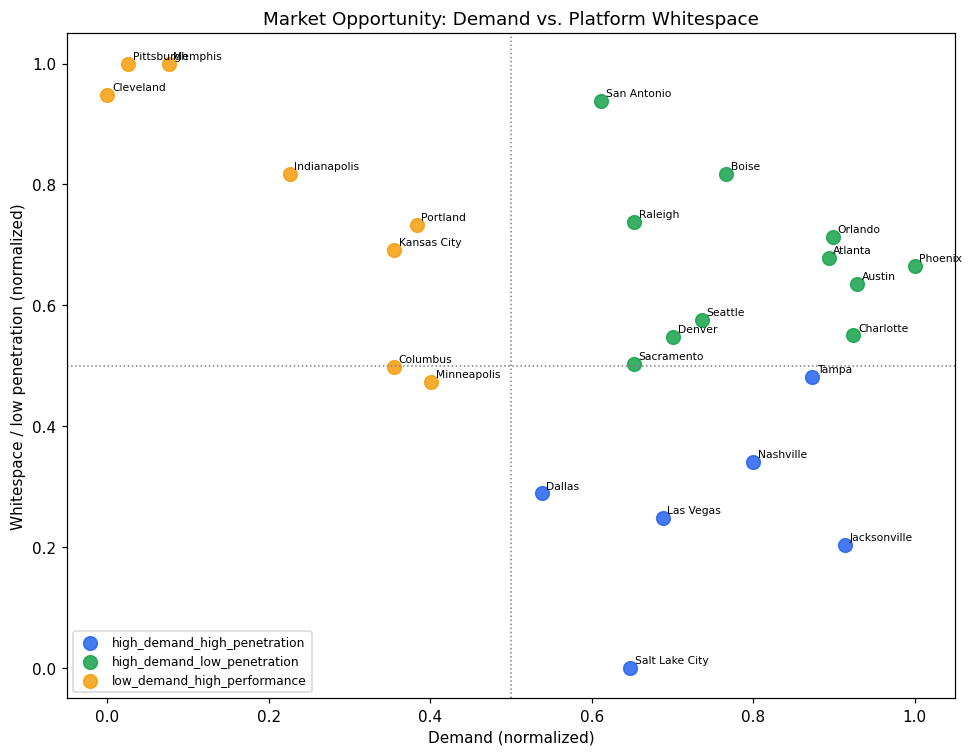

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = {"high_demand_low_penetration": "#16a34a", "high_demand_high_penetration": "#2563eb",
          "low_demand_high_performance": "#f59e0b", "low_priority": "#9ca3af"}
for cls, grp in mo.groupby("market_classification"):
    ax.scatter(grp["demand_norm"], grp["low_penetration_norm"], label=cls,
               color=colors.get(cls, "gray"), s=80, alpha=0.85)
for _, r in mo.iterrows():
    ax.annotate(r["metro_name"].split(",")[0], (r["demand_norm"], r["low_penetration_norm"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Demand (normalized)")
ax.set_ylabel("Whitespace / low penetration (normalized)")
ax.set_title("Market Opportunity: Demand vs. Platform Whitespace")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## Top 8 recommended priority markets

In [4]:
top8 = mo.sort_values("opportunity_score", ascending=False).head(8)
print(top8[["metro_name", "demand_score", "platform_landlords", "activation_rate",
            "paid_conversion_rate", "opportunity_score", "market_classification"]].to_string(index=False))

     metro_name  demand_score  platform_landlords  activation_rate  paid_conversion_rate  opportunity_score        market_classification
    Phoenix, AZ          87.3                2517           0.4128                0.1108             0.6780  high_demand_low_penetration
    Orlando, FL          83.3                2656           0.4202                0.1148             0.6535  high_demand_low_penetration
     Austin, TX          84.5                3038           0.4253                0.1119             0.6427  high_demand_low_penetration
    Atlanta, GA          83.1                2524           0.4013                0.1070             0.6371  high_demand_low_penetration
      Boise, ID          78.1                1743           0.3970                0.1147             0.6286  high_demand_low_penetration
  Charlotte, NC          84.3                2107           0.3916                0.1101             0.6098  high_demand_low_penetration
San Antonio, TX          72.0            

## Sensitivity analysis
The base weighting is 40% demand / 30% whitespace / 30% platform
performance. We re-rank under two alternative weightings to check how
stable the top markets are to the choice of weights.

In [5]:
def score(df, w_demand, w_whitespace, w_perf):
    perf = (df["activation_rate"] + df["paid_conversion_rate"]) / 2
    return w_demand * df["demand_norm"] + w_whitespace * df["low_penetration_norm"] + w_perf * perf

weightings = {
    "Base (40/30/30)": (0.40, 0.30, 0.30),
    "Demand-heavy (60/20/20)": (0.60, 0.20, 0.20),
    "Whitespace-heavy (20/60/20)": (0.20, 0.60, 0.20),
}
rank_table = pd.DataFrame({"metro_name": mo["metro_name"]})
for name, (wd, ww, wp) in weightings.items():
    s = score(mo, wd, ww, wp)
    rank_table[name] = s.rank(ascending=False).astype(int)
rank_table = rank_table.set_index("metro_name")
print(rank_table.sort_values("Base (40/30/30)").head(10))

                 Base (40/30/30)  ...  Whitespace-heavy (20/60/20)
metro_name                        ...                             
Phoenix, AZ                    1  ...                            5
Orlando, FL                    2  ...                            3
Austin, TX                     3  ...                            9
Atlanta, GA                    4  ...                            7
Boise, ID                      5  ...                            2
Charlotte, NC                  6  ...                           13
San Antonio, TX                7  ...                            1
Tampa, FL                      8  ...                           17
Raleigh, NC                    9  ...                            8
Seattle, WA                   10  ...                           14

[10 rows x 3 columns]


## Finding

A handful of metros -- concentrated among the mid-sized Sun Belt markets in
our synthetic data -- rank in the top 5 across all three weighting schemes,
meaning the recommendation is robust to how much you trust "demand" vs.
"whitespace" vs. "current platform performance." Markets that only rank
highly under one specific weighting should be treated as lower-confidence
picks.

**Recommendation:** Prioritize sales/marketing spend on the metros that are
top-8 under the base weighting AND stay top-10 under both sensitivity
weightings -- this is a stronger signal than the base score alone. Treat
this scoring framework as a starting shortlist for deeper market-by-market
due diligence, not a final allocation decision.